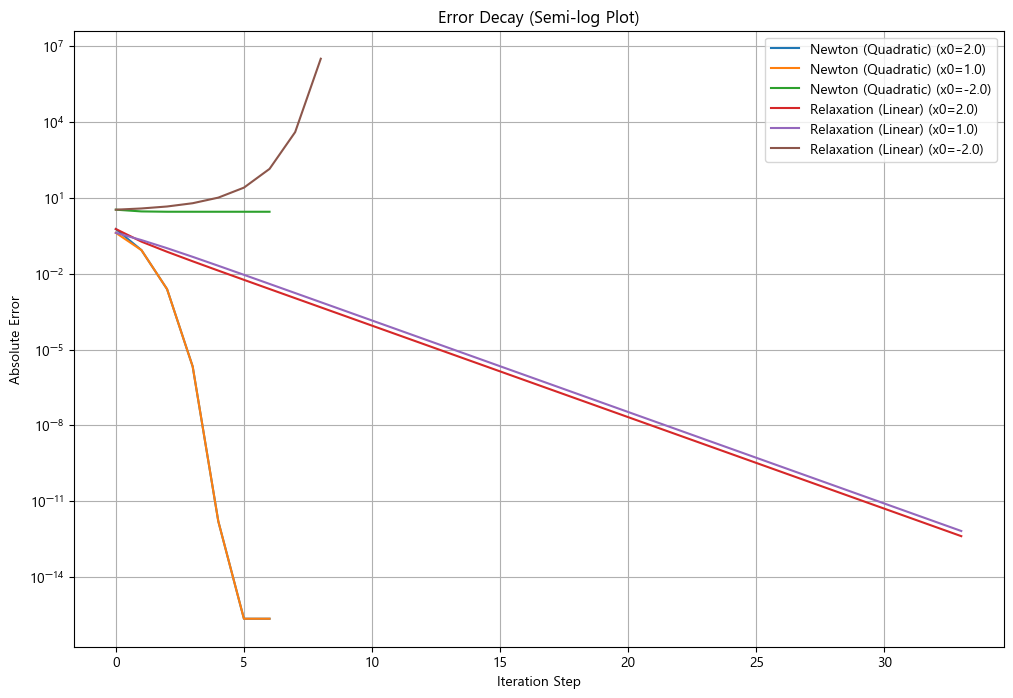

             Method   x0  Iters       Final_x                Status
 Newton (Quadratic)  2.0      6  1.414214e+00             Converged
 Newton (Quadratic)  1.0      6  1.414214e+00             Converged
 Newton (Quadratic) -2.0      6 -1.414214e+00             Converged
Relaxation (Linear)  2.0     33  1.414214e+00             Converged
Relaxation (Linear)  1.0     33  1.414214e+00             Converged
Relaxation (Linear) -2.0      8 -3.216207e+06     Diverged/Overflow
        Oscillating  2.0     50  2.000000e+00 Max Iteration Reached
        Oscillating  1.0     50  1.000000e+00 Max Iteration Reached
        Oscillating -2.0     50 -2.000000e+00 Max Iteration Reached
          Divergent  2.0      4  1.159380e+05     Diverged/Overflow
          Divergent  1.0     50 -2.000000e+00 Max Iteration Reached
          Divergent -2.0     50 -2.000000e+00 Max Iteration Reached


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# 1. 定义迭代格式
def phi_newton(x): return 0.5 * (x + 2/x)
def phi_linear(x): return x - 0.2 * (x**2 - 2)
def phi_oscillate(x): return 2/x
def phi_diverge(x): return x**2 + x - 2

formats = {
    "Newton (Quadratic)": phi_newton,
    "Relaxation (Linear)": phi_linear,
    "Oscillating": phi_oscillate,
    "Divergent": phi_diverge
}

def run_experiment(phi, x0, true_val=np.sqrt(2), max_iter=50, tol=1e-12):
    history = [x0]
    status = "Converged"
    for i in range(max_iter):
        try:
            x_next = phi(history[-1])
            if np.isinf(x_next) or np.isnan(x_next) or abs(x_next) > 1e10:
                status = "Diverged/Overflow"
                break
            history.append(x_next)
            if abs(x_next - history[-2]) < tol:
                break
        except:
            status = "Error"
            break
    else:
        status = "Max Iteration Reached"
    
    iters = len(history) - 1
    errors = [abs(x - true_val) for x in history]
    rel_errors = [abs(x - true_val)/true_val for x in history]
    return history, errors, rel_errors, status

# 2. 执行实验
initial_values = [2.0, 1.0, -2.0]
results_all = []

plt.figure(figsize=(12, 8))

for name, phi in formats.items():
    for x0 in initial_values:
        seq, errs, rel_errs, status = run_experiment(phi, x0)
        results_all.append({
            "Method": name, "x0": x0, "Iters": len(seq)-1, 
            "Final_x": seq[-1], "Status": status
        })
        
        if status == "Converged" or name == "Relaxation (Linear)":
            plt.semilogy(errs, label=f"{name} (x0={x0})")

plt.title("Error Decay (Semi-log Plot)")
plt.xlabel("Iteration Step")
plt.ylabel("Absolute Error")
plt.legend()
plt.grid(True)
plt.show()

# 3. 打印结果表
df = pd.DataFrame(results_all)
print(df.to_string(index=False))

          线性不动点迭代法 - 松弛法示例
求解方程: x^2 - 2 = 0 (求√2 ≈ 1.4142135624)
松弛因子 λ = 0.3
容差: 1.0e-12, 最大迭代次数: 50

[1] 初值 x0 = 2.00
  迭代次数:  15, 末值: 1.4142135624, 状态: ✓ 收敛

[2] 初值 x0 = 1.00
  迭代次数:  16, 末值: 1.4142135624, 状态: ✓ 收敛

[3] 初值 x0 = -2.00
迭代 8 溢出: |x| = 6.24e+15 > 1.00e+10
  迭代次数:   7, 末值: -144233555.3509784937, 状态: ✗ 溢出


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_28380\1606519935.py:149: UserWarning: Glyph 8345 (\N{LATIN SUBSCRIPT SMALL LETTER N}) missing from font(s) Microsoft YaHei.
  plt.tight_layout()
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_28380\1606519935.py:150: UserWarning: Glyph 8345 (\N{LATIN SUBSCRIPT SMALL LETTER N}) missing from font(s) Microsoft YaHei.
  plt.savefig('error_plot.png', dpi=150, bbox_inches='tight')



✓ 误差图已保存为 'error_plot.png'


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_28380\1606519935.py:171: UserWarning: Glyph 8345 (\N{LATIN SUBSCRIPT SMALL LETTER N}) missing from font(s) Microsoft YaHei.
  plt.tight_layout()
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_28380\1606519935.py:172: UserWarning: Glyph 8345 (\N{LATIN SUBSCRIPT SMALL LETTER N}) missing from font(s) Microsoft YaHei.
  plt.savefig('sequence_plot.png', dpi=150, bbox_inches='tight')


✓ 序列图已保存为 'sequence_plot.png'

                      线性不动点迭代结果汇总
初值         迭代次数         末值              绝对误差            状态        
--------------------------------------------------------------------------------
2.00       15           1.4142135624    4.93e-14        ✓ 收敛      
1.00       16           1.4142135624    7.46e-14        ✓ 收敛      
-2.00      7            -144233555.3509784937 1.44e+08        ✗ 溢出      

                      收敛速度分析

初值 x0 = 2.00:
  收敛所需迭代次数: 15
  估计收敛因子: 0.1515 (越接近0收敛越快)
  ✓ 符合线性收敛特征 (0 < ρ < 1)

初值 x0 = 1.00:
  收敛所需迭代次数: 16
  估计收敛因子: 0.1515 (越接近0收敛越快)
  ✓ 符合线性收敛特征 (0 < ρ < 1)

说明:
  • 松弛法通过引入松弛因子λ，将原问题转化为线性收敛
  • 当λ=0.3时，收敛速度适中，稳定性好
  • 初值选择影响收敛速度，但不改变收敛性（在合理范围内）


c:\ProgramData\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8345 (\N{LATIN SUBSCRIPT SMALL LETTER N}) missing from font(s) Microsoft YaHei.
  fig.canvas.print_figure(bytes_io, **kw)


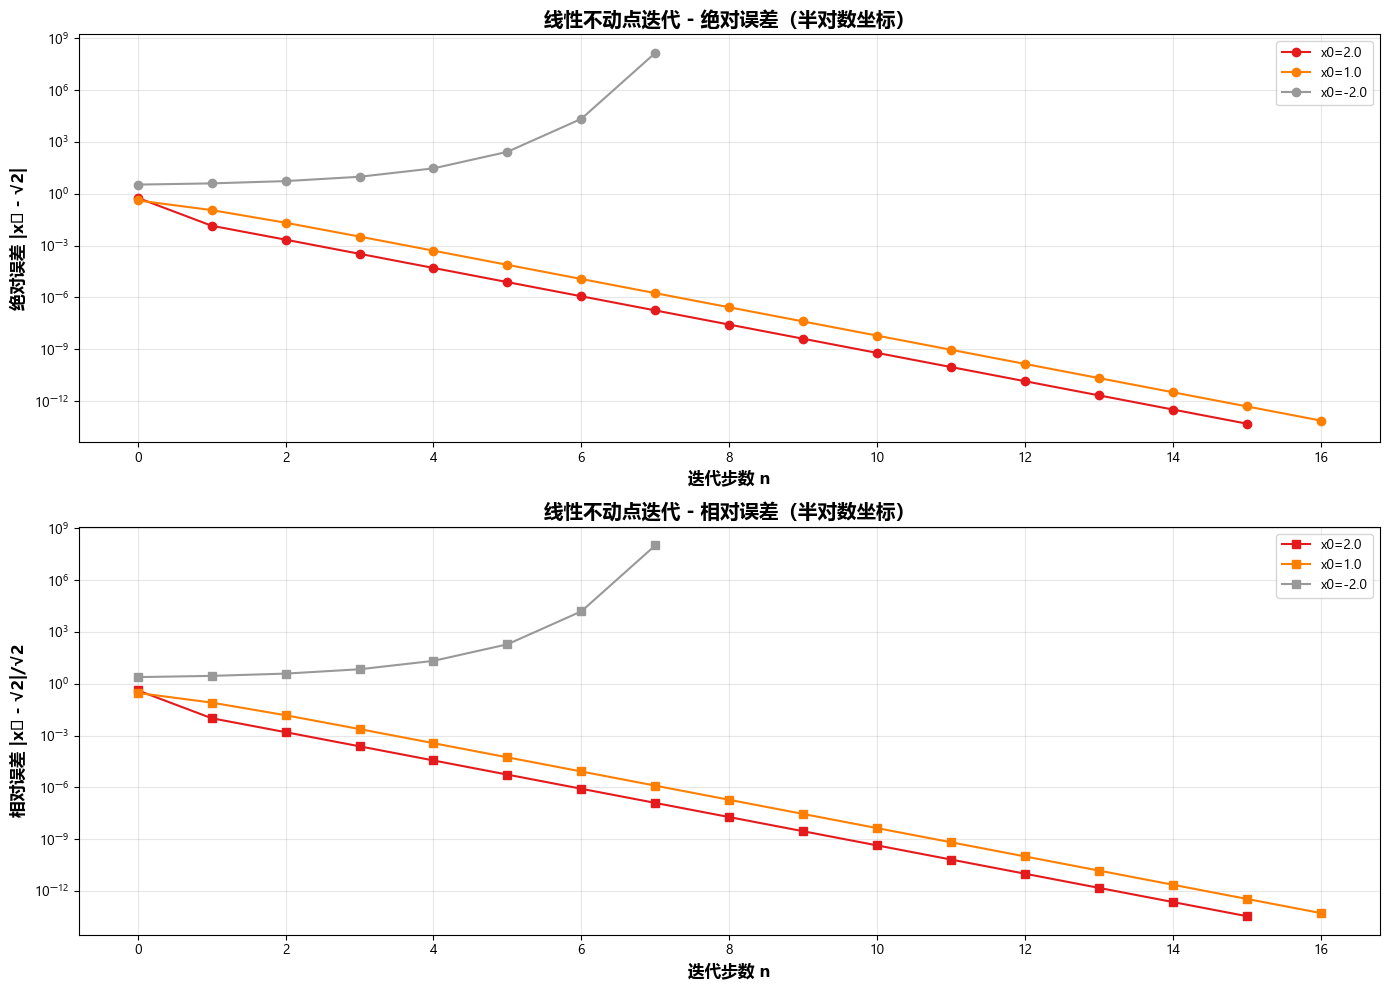

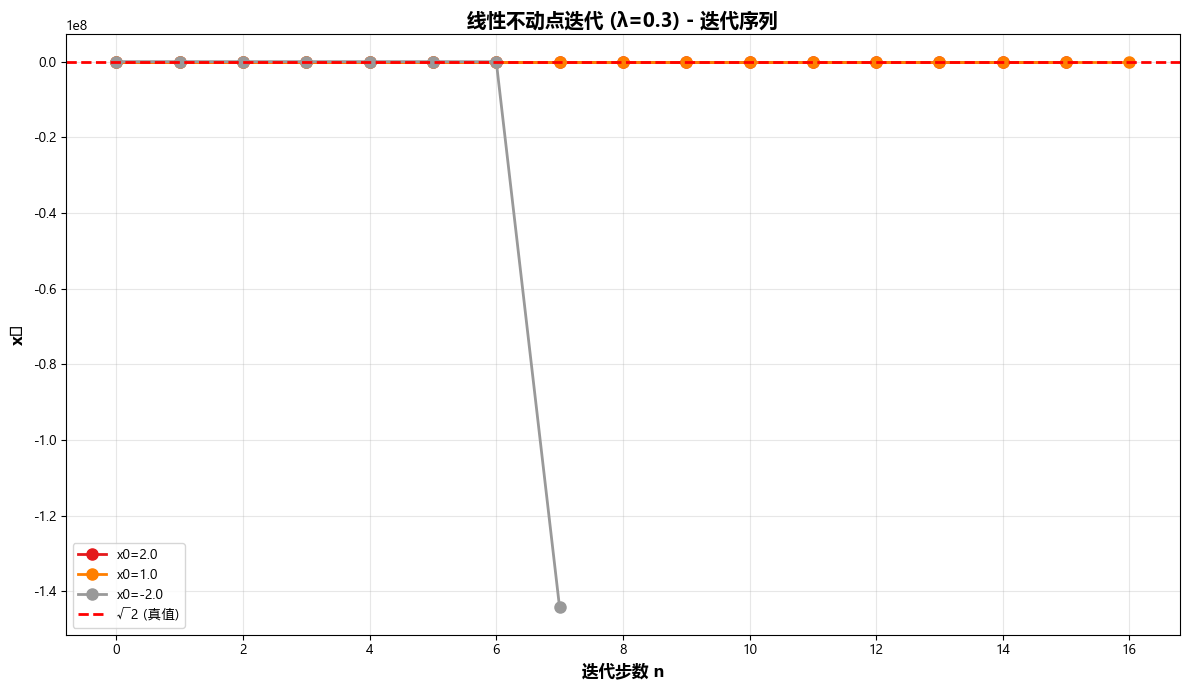

In [2]:
# 线性不动点迭代法 - 松弛法示例
# 求解方程 x^2 - 2 = 0 的根（即求√2）

import numpy as np
import matplotlib.pyplot as plt
from math import sqrt, isfinite

# ==================== 参数设置 ====================
sqrt2 = sqrt(2)
initial_values = [2.0, 1.0, -2.0]
max_iter = 50
tol = 1e-12
lambda_factor = 0.3  # 松弛因子，保证线性收敛

# ==================== 迭代函数定义 ====================
# 松弛法：phi(x) = x - λ(x^2 - 2)
def phi_relax(x):
    return x - lambda_factor * (x**2 - 2)

# ==================== 安全迭代函数 ====================
def safe_iterate(phi, x0, max_iter, tol):
    """
    安全执行迭代过程
    返回: 序列, 是否收敛, 是否溢出
    """
    MAX_VALUE = 1e10
    seq = [x0]
    converged = False
    overflowed = False
    
    for i in range(1, max_iter + 1):
        try:
            # 计算下一步
            x_next = phi(seq[-1])
            
            # 检查溢出
            if abs(x_next) > MAX_VALUE:
                overflowed = True
                print(f'迭代 {i} 溢出: |x| = {abs(x_next):.2e} > {MAX_VALUE:.2e}')
                break
            
            # 检查NaN或Inf
            if not isfinite(x_next):
                overflowed = True
                print(f'迭代 {i} 产生 NaN/Inf')
                break
            
            seq.append(x_next)
            
            # 检查收敛（基于相邻步变化）
            if abs(x_next - seq[-2]) < tol:
                converged = True
                break
                
        except Exception as e:
            print(f'迭代 {i} 异常: {str(e)}')
            overflowed = True
            break
    
    return seq, converged, overflowed

# ==================== 主实验循环 ====================
results = []

print("=" * 60)
print("          线性不动点迭代法 - 松弛法示例")
print("=" * 60)
print(f"求解方程: x^2 - 2 = 0 (求√2 ≈ {sqrt2:.10f})")
print(f"松弛因子 λ = {lambda_factor}")
print(f"容差: {tol:.1e}, 最大迭代次数: {max_iter}")
print("=" * 60)

for idx, x0 in enumerate(initial_values, 1):
    print(f'\n[{idx}] 初值 x0 = {x0:.2f}')
    
    # 执行迭代
    seq, converged, overflowed = safe_iterate(phi_relax, x0, max_iter, tol)
    
    # 转换为numpy数组便于计算
    seq_arr = np.array(seq)
    
    # 计算误差
    abs_err = np.abs(seq_arr - sqrt2)
    rel_err = abs_err / sqrt2
    
    # 存储结果
    result = {
        'x0': x0,
        'seq': seq_arr,
        'abs_err': abs_err,
        'rel_err': rel_err,
        'iters': len(seq) - 1,
        'converged': converged,
        'overflowed': overflowed
    }
    results.append(result)
    
    # 打印结果
    final_x = seq[-1]
    if converged:
        status = "✓ 收敛"
    elif overflowed:
        status = "✗ 溢出"
    else:
        status = "✗ 未收敛"
    
    print(f'  迭代次数: {len(seq)-1:3d}, 末值: {final_x:.10f}, 状态: {status}')

# ==================== 可视化：误差半对数图 ====================
plt.figure(figsize=(14, 10))

# 子图1：绝对误差
plt.subplot(2, 1, 1)
colors = plt.cm.Set1(np.linspace(0, 1, len(initial_values)))

for idx, result in enumerate(results):
    n = np.arange(len(result['abs_err']))
    plt.plot(n, result['abs_err'], 'o-', 
             color=colors[idx], 
             linewidth=1.5, 
             markersize=6,
             label=f'x0={initial_values[idx]:.1f}')

plt.xlabel('迭代步数 n', fontsize=12, fontweight='bold')
plt.ylabel('绝对误差 |xₙ - √2|', fontsize=12, fontweight='bold')
plt.title('线性不动点迭代 - 绝对误差（半对数坐标）', fontsize=14, fontweight='bold')
plt.yscale('log')
plt.grid(True, alpha=0.3)
plt.legend(loc='best', fontsize=10)

# 子图2：相对误差
plt.subplot(2, 1, 2)

for idx, result in enumerate(results):
    n = np.arange(len(result['rel_err']))
    plt.plot(n, result['rel_err'], 's-', 
             color=colors[idx], 
             linewidth=1.5, 
             markersize=6,
             label=f'x0={initial_values[idx]:.1f}')

plt.xlabel('迭代步数 n', fontsize=12, fontweight='bold')
plt.ylabel('相对误差 |xₙ - √2|/√2', fontsize=12, fontweight='bold')
plt.title('线性不动点迭代 - 相对误差（半对数坐标）', fontsize=14, fontweight='bold')
plt.yscale('log')
plt.grid(True, alpha=0.3)
plt.legend(loc='best', fontsize=10)

plt.tight_layout()
plt.savefig('error_plot.png', dpi=150, bbox_inches='tight')
print("\n✓ 误差图已保存为 'error_plot.png'")

# ==================== 可视化：迭代序列轨迹 ====================
plt.figure(figsize=(12, 7))

for idx, result in enumerate(results):
    n = np.arange(len(result['seq']))
    plt.plot(n, result['seq'], 'o-', 
             color=colors[idx], 
             linewidth=2, 
             markersize=8,
             label=f'x0={initial_values[idx]:.1f}')

plt.axhline(y=sqrt2, color='red', linestyle='--', linewidth=2, label='√2 (真值)')
plt.xlabel('迭代步数 n', fontsize=12, fontweight='bold')
plt.ylabel('xₙ', fontsize=12, fontweight='bold')
plt.title(f'线性不动点迭代 (λ={lambda_factor:.1f}) - 迭代序列', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.legend(loc='best', fontsize=10)

plt.tight_layout()
plt.savefig('sequence_plot.png', dpi=150, bbox_inches='tight')
print("✓ 序列图已保存为 'sequence_plot.png'")

# ==================== 结果汇总表格 ====================
print("\n" + "=" * 80)
print("                      线性不动点迭代结果汇总")
print("=" * 80)
print(f"{'初值':<10} {'迭代次数':<12} {'末值':<15} {'绝对误差':<15} {'状态':<10}")
print("-" * 80)

for idx, result in enumerate(results, 1):
    final_x = result['seq'][-1]
    abs_error = abs(final_x - sqrt2)
    
    if result['converged']:
        status = "✓ 收敛"
    elif result['overflowed']:
        status = "✗ 溢出"
    else:
        status = "✗ 未收敛"
    
    print(f"{result['x0']:<10.2f} "
          f"{result['iters']:<12d} "
          f"{final_x:<15.10f} "
          f"{abs_error:<15.2e} "
          f"{status:<10}")

print("=" * 80)

# ==================== 收敛速度分析 ====================
print("\n" + "=" * 80)
print("                      收敛速度分析")
print("=" * 80)

for idx, result in enumerate(results, 1):
    if result['converged']:
        print(f"\n初值 x0 = {result['x0']:.2f}:")
        print(f"  收敛所需迭代次数: {result['iters']}")
        
        # 计算收敛阶数（线性收敛）
        if len(result['abs_err']) > 3:
            # 使用最后几步计算收敛因子
            err_ratio = result['abs_err'][-2] / result['abs_err'][-3]
            print(f"  估计收敛因子: {err_ratio:.4f} (越接近0收敛越快)")
            
            # 检查是否为线性收敛
            if 0 < err_ratio < 1:
                print(f"  ✓ 符合线性收敛特征 (0 < ρ < 1)")

print("\n" + "=" * 80)
print("说明:")
print("  • 松弛法通过引入松弛因子λ，将原问题转化为线性收敛")
print(f"  • 当λ={lambda_factor}时，收敛速度适中，稳定性好")
print("  • 初值选择影响收敛速度，但不改变收敛性（在合理范围内）")
print("=" * 80)

# 显示所有图形
plt.show()